In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs found:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ GPU е наличен и memory growth е включен.")
else:
    print("❌ TensorFlow не вижда GPU. Ще тренира на CPU.")

TensorFlow version: 2.10.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU е наличен и memory growth е включен.


In [2]:
DATASET_CSV = r"D:\Магистър\Общ проект\dataset_mri_pet_labels.csv"

dataset_df = pd.read_csv(DATASET_CSV)

print("Dataset shape:", dataset_df.shape)
display(dataset_df.head())

print("Разпределение по диагноза:")
print(dataset_df["diagnosis"].value_counts())

Dataset shape: (458, 5)


,subject_id,mri_path,pet_path,diagnosis,label
0,002_S_0295,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
1,002_S_0413,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
2,002_S_0685,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
3,002_S_1261,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
4,002_S_1280,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0


Разпределение по диагноза:
diagnosis
CN    311
AD    147
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    dataset_df,
    test_size=0.20,
    random_state=42,
    stratify=dataset_df["label"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=42,
    stratify=train_val_df["label"]
)

print("Train:", len(train_df))
print(train_df["diagnosis"].value_counts())
print()

print("Validation:", len(val_df))
print(val_df["diagnosis"].value_counts())
print()

print("Test:", len(test_df))
print(test_df["diagnosis"].value_counts())

Train: 292
diagnosis
CN    199
AD     93
Name: count, dtype: int64

Validation: 74
diagnosis
CN    50
AD    24
Name: count, dtype: int64

Test: 92
diagnosis
CN    62
AD    30
Name: count, dtype: int64


In [4]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])  # CN = 0, AD = 1

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: class_weights_values[0],
    1: class_weights_values[1]
}

print("Class weights:", class_weights)

Class weights: {0: 0.7336683417085427, 1: 1.5698924731182795}


In [5]:
BATCH_SIZE = 1
INPUT_SHAPE_SINGLE = (64, 64, 64, 1)

def downsample_volume(volume):
    return volume[::2, ::2, ::2]

def load_sample_dual(mri_path, pet_path, label):
    mri_path = mri_path.decode("utf-8")
    pet_path = pet_path.decode("utf-8")

    mri = np.load(mri_path).astype("float32")
    pet = np.load(pet_path).astype("float32")

    mri = downsample_volume(mri)
    pet = downsample_volume(pet)

    mri = np.expand_dims(mri, axis=-1)
    pet = np.expand_dims(pet, axis=-1)

    return mri, pet, np.float32(label)

def tf_load_sample_dual(mri_path, pet_path, label):
    mri, pet, y = tf.numpy_function(
        load_sample_dual,
        [mri_path, pet_path, label],
        [tf.float32, tf.float32, tf.float32]
    )

    mri.set_shape(INPUT_SHAPE_SINGLE)
    pet.set_shape(INPUT_SHAPE_SINGLE)
    y.set_shape(())

    return {"mri_input": mri, "pet_input": pet}, y

def make_dataset_dual(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["mri_path"].values,
        df["pet_path"].values,
        df["label"].values.astype("float32")
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(tf_load_sample_dual, num_parallel_calls=1)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(1)

    return ds

train_ds = make_dataset_dual(train_df, shuffle=True)
val_ds = make_dataset_dual(val_df)
test_ds = make_dataset_dual(test_df)

for batch_x, batch_y in train_ds.take(1):
    print(batch_x.keys())
    print("MRI:", batch_x["mri_input"].shape)
    print("PET:", batch_x["pet_input"].shape)
    print("Y:", batch_y.shape)

dict_keys(['mri_input', 'pet_input'])
MRI: (1, 64, 64, 64, 1)
PET: (1, 64, 64, 64, 1)
Y: (1,)


In [6]:
import tensorflow as tf

def binary_focal_loss(gamma=2.0, alpha=0.65):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)

        return tf.reduce_mean(alpha_factor * modulating_factor * bce)

    return loss

In [7]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

def conv_block_3d(x, filters, name):
    x = layers.Conv3D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("relu", name=f"{name}_relu")(x)
    x = layers.MaxPooling3D(2, name=f"{name}_pool")(x)
    return x

def build_branch(input_tensor, branch_name):
    x = conv_block_3d(input_tensor, 8,  f"{branch_name}_block1")
    x = conv_block_3d(x,            16, f"{branch_name}_block2")
    x = conv_block_3d(x,            32, f"{branch_name}_block3")

    avg = layers.GlobalAveragePooling3D(name=f"{branch_name}_avg")(x)
    maxp = layers.GlobalMaxPooling3D(name=f"{branch_name}_max")(x)

    x = layers.Concatenate(name=f"{branch_name}_avgmax")([avg, maxp])

    x = layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{branch_name}_dense"
    )(x)

    return x

def build_model5_attention_fusion(input_shape=(64, 64, 64, 1)):
    mri_input = layers.Input(shape=input_shape, name="mri_input")
    pet_input = layers.Input(shape=input_shape, name="pet_input")

    mri_features = build_branch(mri_input, "mri")
    pet_features = build_branch(pet_input, "pet")

    fusion = layers.Concatenate(name="fusion_concat")([mri_features, pet_features])

    # Attention-like gating
    gate = layers.Dense(64, activation="sigmoid", name="fusion_gate")(fusion)
    gated = layers.Multiply(name="gated_fusion")([fusion, gate])

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="classifier_dense_64"
    )(gated)
    x = layers.Dropout(0.30, name="dropout_1")(x)

    x = layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="classifier_dense_32"
    )(x)
    x = layers.Dropout(0.20, name="dropout_2")(x)

    output = layers.Dense(1, activation="sigmoid", name="classification_output")(x)

    model = models.Model(
        inputs={"mri_input": mri_input, "pet_input": pet_input},
        outputs=output,
        name="Model5_DualBranch_AttentionFusion"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

model5 = build_model5_attention_fusion()
model5.summary()

Model: "Model5_DualBranch_AttentionFusion"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 mri_input (InputLayer)         [(None, 64, 64, 64,  0           []                               
                                 1)]                                                              
                                                                                                  
 pet_input (InputLayer)         [(None, 64, 64, 64,  0           []                               
                                 1)]                                                              
                                                                                                  
 mri_block1_conv (Conv3D)       (None, 64, 64, 64,   216         ['mri_input[0][0]']              
                                8)                                

In [8]:
callbacks5 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "model5_dualbranch_attention_fusion.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

In [9]:
history5 = model5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks5
)

Epoch 1/40
291/292 [============================>.] - ETA: 0s - loss: 0.7510 - accuracy: 0.6186 - precision: 0.3594 - sensitivity: 0.2473 - auc: 0.5539
Epoch 1: val_auc improved from -inf to 0.38458, saving model to model5_dualbranch_attention_fusion.keras
292/292 [==============================] - 20s 57ms/step - loss: 0.7489 - accuracy: 0.6199 - precision: 0.3594 - sensitivity: 0.2473 - auc: 0.5555 - val_loss: 0.6884 - val_accuracy: 0.6757 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00 - val_auc: 0.3846 - lr: 5.0000e-05
Epoch 2/40
291/292 [============================>.] - ETA: 0s - loss: 0.7112 - accuracy: 0.6220 - precision: 0.3111 - sensitivity: 0.1505 - auc: 0.5131
Epoch 2: val_auc improved from 0.38458 to 0.43208, saving model to model5_dualbranch_attention_fusion.keras
292/292 [==============================] - 16s 55ms/step - loss: 0.7098 - accuracy: 0.6233 - precision: 0.3111 - sensitivity: 0.1505 - auc: 0.5140 - val_loss: 0.6747 - val_accuracy: 0.6892 - val_precis

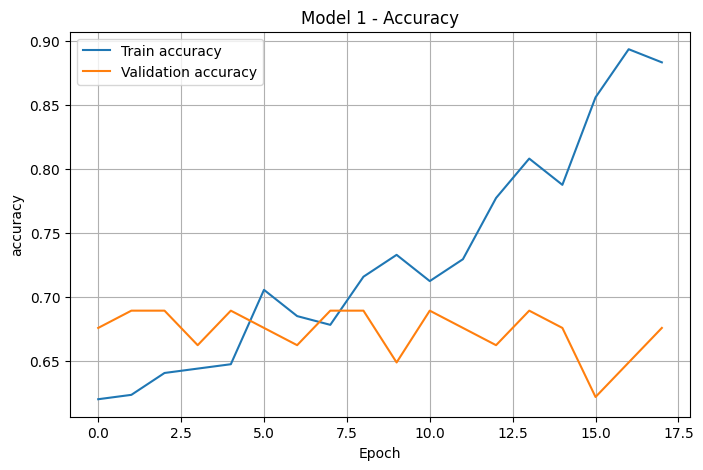

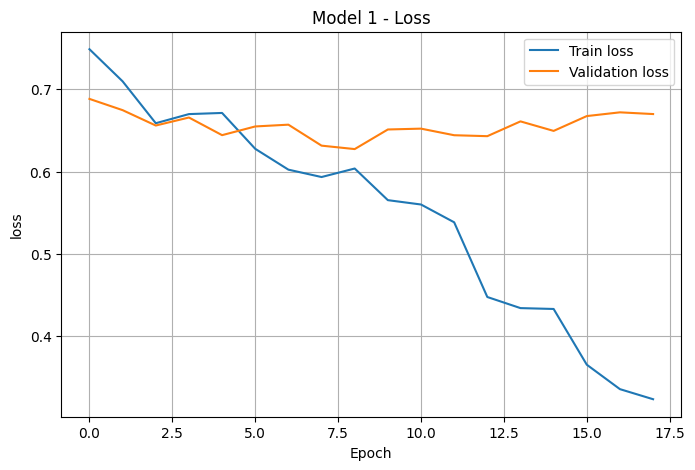

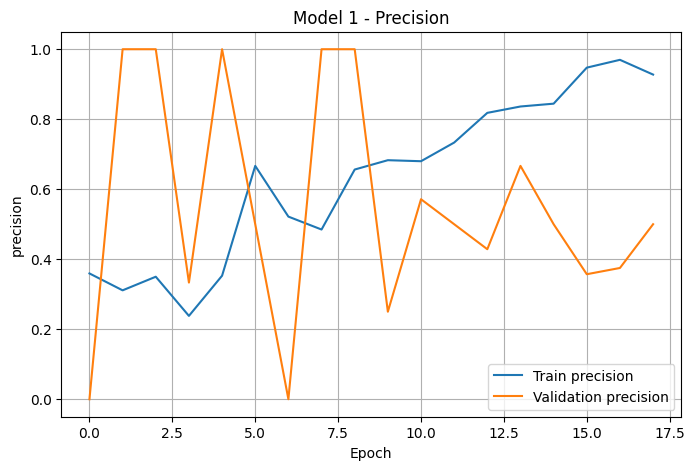

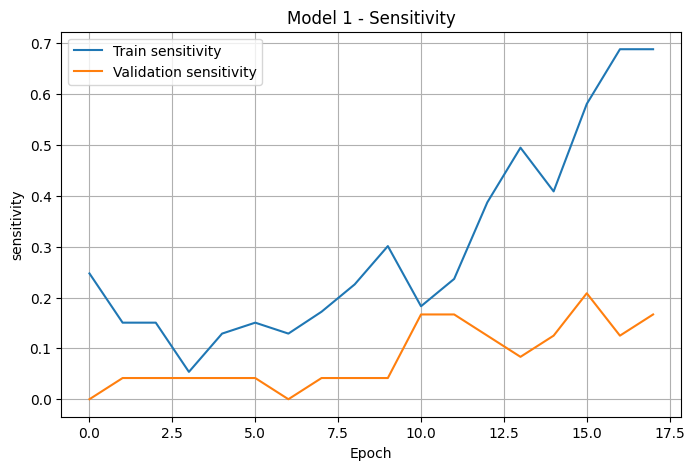

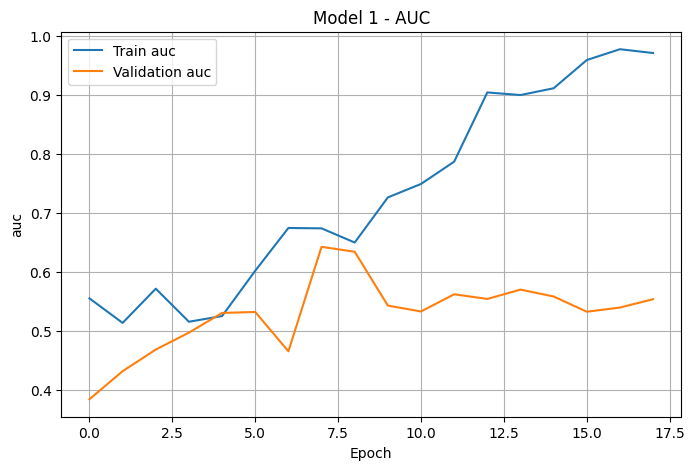

In [10]:
import matplotlib.pyplot as plt

def plot_metric(history, metric, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[metric], label=f"Train {metric}")
    plt.plot(history.history[f"val_{metric}"], label=f"Validation {metric}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

plot_metric(history5, "accuracy", "Model 1 - Accuracy", "model1_accuracy.png")
plot_metric(history5, "loss", "Model 1 - Loss", "model1_loss.png")
plot_metric(history5, "precision", "Model 1 - Precision", "model1_precision.png")
plot_metric(history5, "sensitivity", "Model 1 - Sensitivity", "model1_sensitivity.png")
plot_metric(history5, "auc", "Model 1 - AUC", "model1_auc.png")

In [11]:
test_results_4 = model5.evaluate(test_ds, verbose=1)

print("Model 4 Test results:")
for name, value in zip(model5.metrics_names, test_results_4):
    print(f"{name}: {value:.4f}")

92/92 [==============================] - 3s 36ms/step - loss: 0.6383 - accuracy: 0.6630 - precision: 0.0000e+00 - sensitivity: 0.0000e+00 - auc: 0.5804
Model 4 Test results:
loss: 0.6383
accuracy: 0.6630
precision: 0.0000
sensitivity: 0.0000
auc: 0.5804


In [12]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd
import numpy as np

y_true_5 = []
y_prob_5 = []

for batch_x, y_batch in test_ds:
    preds = model5.predict(batch_x, verbose=0)
    y_prob_5.extend(preds.ravel())
    y_true_5.extend(y_batch.numpy().ravel())

y_true_5 = np.array(y_true_5).astype(int)
y_prob_5 = np.array(y_prob_5)

thresholds = np.arange(0.10, 0.71, 0.05)
rows = []

for th in thresholds:
    y_pred = (y_prob_5 >= th).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_5,
        y_pred,
        average="binary",
        zero_division=0
    )

    acc = accuracy_score(y_true_5, y_pred)
    cm_tmp = confusion_matrix(y_true_5, y_pred)
    tn_tmp, fp_tmp, fn_tmp, tp_tmp = cm_tmp.ravel()

    rows.append({
        "threshold": round(th, 2),
        "accuracy": round(acc, 4),
        "precision": round(precision, 4),
        "sensitivity": round(recall, 4),
        "f1": round(f1, 4),
        "TN": tn_tmp,
        "FP": fp_tmp,
        "FN": fn_tmp,
        "TP": tp_tmp
    })

threshold_df_5 = pd.DataFrame(rows)
display(threshold_df_5.sort_values("f1", ascending=False))

,threshold,accuracy,precision,sensitivity,f1,TN,FP,FN,TP
2,0.20,0.3370,0.3297,1.0000,0.4959,1,61,0,30
3,0.25,0.3370,0.3297,1.0000,0.4959,1,61,0,30
0,0.10,0.3261,0.3261,1.0000,0.4918,0,62,0,30
1,0.15,0.3261,0.3261,1.0000,0.4918,0,62,0,30
4,0.30,0.3804,0.3291,0.8667,0.4771,9,53,4,26
5,0.35,0.5326,0.3725,0.6333,0.4691,30,32,11,19
6,0.40,0.6304,0.4167,0.3333,0.3704,48,14,20,10
7,0.45,0.6739,0.5000,0.1333,0.2105,58,4,26,4
8,0.50,0.6630,0.0000,0.0000,0.0000,61,1,30,0
9,0.55,0.6739,0.0000,0.0000,0.0000,62,0,30,0


In [13]:
threshold = 0.35

y_pred_5 = (y_prob_5 >= threshold).astype(int)

cm5 = confusion_matrix(y_true_5, y_pred_5)
tn5, fp5, fn5, tp5 = cm5.ravel()

print("Model 5 Confusion Matrix:")
print(cm5)
print()
print(f"TN: {tn5}")
print(f"FP: {fp5}")
print(f"FN: {fn5}")
print(f"TP: {tp5}")
print()

print(classification_report(
    y_true_5,
    y_pred_5,
    target_names=["CN", "AD"],
    zero_division=0
))

Model 5 Confusion Matrix:
[[30 32]
 [11 19]]

TN: 30
FP: 32
FN: 11
TP: 19

              precision    recall  f1-score   support

          CN       0.73      0.48      0.58        62
          AD       0.37      0.63      0.47        30

    accuracy                           0.53        92
   macro avg       0.55      0.56      0.53        92
weighted avg       0.61      0.53      0.55        92



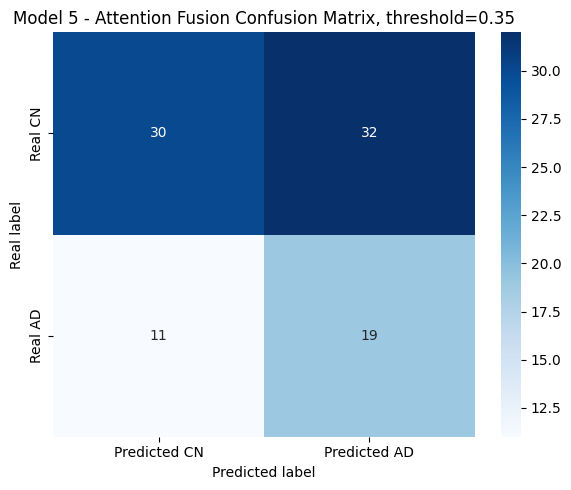

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm5,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted CN", "Predicted AD"],
    yticklabels=["Real CN", "Real AD"]
)

plt.title(f"Model 5 - Attention Fusion Confusion Matrix, threshold={threshold}")
plt.ylabel("Real label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("model5_attention_fusion_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
test_results = model5.evaluate(test_ds, verbose=1)

print("Test results:")
for name, value in zip(model5.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

92/92 [==============================] - 2s 23ms/step - loss: 0.6383 - accuracy: 0.6630 - precision: 0.0000e+00 - sensitivity: 0.0000e+00 - auc: 0.5804
Test results:
loss: 0.6383
accuracy: 0.6630
precision: 0.0000
sensitivity: 0.0000
auc: 0.5804
